# **2. Data Cleaning & First Fair-Lending Descriptive Pass**

**Inputs from 1_data_load.ipynb:**
- `hmda_2024_typed.parquet` (12,229,298 × 63)
- `hmda_2024_decisions.parquet` (8,276,018 × 64, 74.63% approval rate)
- `1_column_dictionary.csv`

**Focus:**
- **Part A — Clean up what 1_data_load.ipynb found broken:** invalid/outlier values in `income` and `loan_to_value_ratio` (and neighboring columns), 29k+ exact duplicate rows, and a documented missingness strategy.
- **Part B — First real fair-lending descriptive pass:** approval rates and denial reasons by race/ethnicity/sex on the cleaned decision subset. **Still descriptive only** — no regression adjustment or significance testing (that's Day 3).

**Not for this file:** regression-adjusted disparity testing, statistical significance tests, proxy-discrimination analysis, feature engineering, train/test split, model training.


### **Setup**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)

DATA_DIR = '../data/processed/'

decisions_path = DATA_DIR + 'hmda_2024_decisions.parquet'
dictionary_path = '1_column_dictionary.csv'

df = pd.read_parquet(decisions_path)
print(f"Loaded {decisions_path}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Approval rate (raw, as loaded): {df['approved'].mean():.2%}")


Loaded ../data/processed/hmda_2024_decisions.parquet
Shape: 8,276,018 rows x 66 columns
Approval rate (raw, as loaded): 74.63%


---
### **Step 1 — Investigate & Fix the Outlier / Invalid-Value Problems**

Notebook1 flagged `income` with a minimum of **-155,317** (thousands of $) and `loan_to_value_ratio`
with a mean of **2,741** (std ~4.36M) — both are impossible for real values. We investigate
before capping: is this a handful of extreme rows, or systemic?


#### **1.1 — Extended percentile view (1st/5th/95th/99th/99.9th)**

In [2]:
outlier_cols = ['income', 'loan_amount', 'loan_to_value_ratio',
                'property_value', 'interest_rate', 'rate_spread']

percentiles = [0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999]

pct_table = df[outlier_cols].describe(percentiles=percentiles).T
pct_table = pct_table[['count', 'mean', 'std', 'min', '0.1%', '1%', '5%',
                       '50%', '95%', '99%', '99.9%', 'max']]
pct_table


,count,mean,std,min,0.1%,1%,5%,50%,95%,99%,99.9%,max
income,7768743.0,188.822281,3.956404e+04,-155317.000,0.000000,0.00,32.00,104.000000,362.00,8.100000e+02,3.120000e+03,1.000000e+08
loan_amount,8276018.0,299442.156250,1.974081e+06,5000.000,5000.000000,15000.00,35000.00,205000.000000,725000.00,1.465000e+06,5.995000e+06,2.650005e+09
loan_to_value_ratio,7438582.0,2741.126953,4.360819e+06,0.001,0.911162,9.43,25.59,78.760002,100.00,1.049700e+02,1.758842e+02,1.093680e+10
property_value,7743138.0,559093.250000,4.384118e+06,5000.000,25000.000000,65000.00,125000.00,385000.000000,1255000.00,2.615000e+06,1.061500e+07,2.147484e+09
interest_rate,5954338.0,7.117909,1.706266e+00,0.000,0.000000,1.00,5.25,6.875000,10.25,1.225000e+01,1.487500e+01,2.253900e+01
rate_spread,5412143.0,0.506853,3.529585e+00,-2650.000,-8.140000,-5.95,-1.24,0.321000,3.35,5.610000e+00,7.950000e+00,3.960000e+03


#### **1.2 — Inspect the worst offenders directly**

In [3]:
# Negative / impossible income
neg_income = df.loc[df['income'] < 0]
print(f"Rows with negative income: {len(neg_income):,} "
      f"({len(neg_income) / len(df):.4%} of decision subset)")
neg_income[['income', 'loan_amount', 'loan_to_value_ratio', 'derived_race',
            'derived_sex', 'loan_purpose']].head(10)


Rows with negative income: 7,182 (0.0868% of decision subset)


,income,loan_amount,loan_to_value_ratio,derived_race,derived_sex,loan_purpose
77417,-663.0,1045000.0,18.181999,Asian,Joint,31
78966,-48.0,1265000.0,90.000000,White,Joint,1
96409,-30.0,1205000.0,55.172001,White,Joint,1
96898,-64.0,445000.0,90.000000,Race Not Available,Sex Not Available,1
99274,-35.0,165000.0,57.820999,White,Male,31
99337,-104.0,145000.0,41.143002,Race Not Available,Male,31
100557,-9.0,255000.0,101.099998,White,Male,31
100597,-86.0,205000.0,38.180000,Black or African American,Female,31
102070,-7.0,225000.0,49.236000,White,Male,31
102324,-31.0,365000.0,90.000000,White,Joint,4


In [4]:
# Extreme LTV — realistically LTV should sit ~0-200%
extreme_ltv = df.loc[df['loan_to_value_ratio'] > 500]
print(f"Rows with LTV > 500%: {len(extreme_ltv):,} "
      f"({len(extreme_ltv) / len(df):.4%} of decision subset)")
print()
print("Distribution of LTV magnitude among the extreme rows "
      "(helps spot a systemic pattern, e.g. misplaced decimal points):")
extreme_ltv['loan_to_value_ratio'].describe(percentiles=[0.5, 0.9, 0.99])


Rows with LTV > 500%: 2,150 (0.0260% of decision subset)

Distribution of LTV magnitude among the extreme rows (helps spot a systemic pattern, e.g. misplaced decimal points):


count    2.150000e+03
mean     9.230592e+06
std      2.563974e+08
min      5.000040e+02
50%      9.999990e+02
90%      4.547576e+04
99%      2.695932e+07
max      1.093680e+10
Name: loan_to_value_ratio, dtype: float64

In [5]:
# Sanity check on loan_amount / property_value for the same extreme-LTV rows —
# is LTV wrong because loan_amount is wrong, property_value is wrong, or both?
extreme_ltv[['loan_amount', 'property_value', 'loan_to_value_ratio']].head(10)


,loan_amount,property_value,loan_to_value_ratio
102608,145000.0,5000.0,1.400000e+07
115584,55000.0,105000.0,5.060930e+02
212673,125000.0,25000.0,5.166670e+02
223207,25000.0,505000.0,2.996890e+03
223238,95000.0,35000.0,8.890000e+02
223252,65000.0,65000.0,8.083330e+02
223481,65000.0,5000.0,2.166667e+04
224174,125000.0,5000.0,2.826941e+04
232154,235000.0,5000.0,4.897453e+04
236927,185000.0,5000.0,5.265714e+04


**Findings to document here after running the cells above:**
- Are the negative-income rows a small, isolated set, or tied to a specific `loan_purpose` /
  `derived_race` / lender pattern? -> Rows with negative income: 7,182 (0.0868% of decision subset)
- Do the extreme-LTV rows look like a decimal-point or unit error (e.g. LTV stored as a raw
  ratio × 100 twice), or plausibly a handful of exotic/commercial loans? -> eg values of extreme LTV: 8.890000e+02,5.060930e+02,4.897453e+04,2.826941e+04,etc. Rows with LTV > 500%: 2,150 (0.0260% of decision subset)
- Repeat this same "look at the raw rows" check for `property_value`, `interest_rate`, and
  `rate_spread` using the percentile table above to pick sensible thresholds.


#### **1.3 — Decide and apply cleaning rules**

In [6]:
# --- Cleaning rules (documented) ---------------------------------------------
# income:                  negative values are impossible -> null out.
#                           cap remaining extreme upper tail at the 99.5th pct
#                           (percentile-based cap, not an arbitrary dollar figure).
# loan_to_value_ratio:      realistic range is ~0-200%. Anything above 500% is
#                           treated as a data error and nulled out (not capped,
#                           since we have no reliable way to guess the true value).
# loan_amount:              legitimate large loans exist -> cap at 99.5th pct
#                           rather than dropping, and flag capped rows.
# property_value:           same treatment as loan_amount -> cap at 99.5th pct, flag.
# interest_rate / rate_spread: cap at 99.5th / floor at 0.5th pct — capture likely
#                           entry errors (e.g. negative rates) without discarding rows.

rules_log = []

def apply_rule(colname, mask, action):
    n = int(mask.sum())
    pct = n / len(df)
    rules_log.append({'column': colname, 'rule': action,
                       'rows_affected': n, 'pct_of_decision_subset': pct})
    return n, pct

# income: null negatives, then cap upper tail
neg_mask = df['income'] < 0
df.loc[neg_mask, 'income'] = np.nan
apply_rule('income', neg_mask, 'negative values set to NaN')

income_cap = df['income'].quantile(0.995)
cap_mask = df['income'] > income_cap
df.loc[cap_mask, 'income'] = income_cap
apply_rule('income', cap_mask, f'capped at 99.5th pct ({income_cap:,.0f})')

# loan_to_value_ratio: null anything outside a realistic 0-200% band,
# treat 200-500% as suspicious-but-plausible and leave for now, >500% as error
ltv_bad_mask = (df['loan_to_value_ratio'] < 0) | (df['loan_to_value_ratio'] > 500)
df.loc[ltv_bad_mask, 'loan_to_value_ratio'] = np.nan
apply_rule('loan_to_value_ratio', ltv_bad_mask, 'values <0 or >500 set to NaN')

# loan_amount: cap rather than drop
loan_amount_cap = df['loan_amount'].quantile(0.995)
la_mask = df['loan_amount'] > loan_amount_cap
df.loc[la_mask, 'loan_amount'] = loan_amount_cap
apply_rule('loan_amount', la_mask, f'capped at 99.5th pct ({loan_amount_cap:,.0f})')

# property_value: cap rather than drop
pv_cap = df['property_value'].quantile(0.995)
pv_mask = df['property_value'] > pv_cap
df.loc[pv_mask, 'property_value'] = pv_cap
apply_rule('property_value', pv_mask, f'capped at 99.5th pct ({pv_cap:,.0f})')

# interest_rate: null implausible negatives, cap extreme upper tail
ir_neg_mask = df['interest_rate'] < 0
df.loc[ir_neg_mask, 'interest_rate'] = np.nan
apply_rule('interest_rate', ir_neg_mask, 'negative values set to NaN')

ir_cap = df['interest_rate'].quantile(0.999)
ir_mask = df['interest_rate'] > ir_cap
df.loc[ir_mask, 'interest_rate'] = ir_cap
apply_rule('interest_rate', ir_mask, f'capped at 99.9th pct ({ir_cap:.2f})')

# rate_spread: same treatment
rs_cap_hi = df['rate_spread'].quantile(0.999)
rs_cap_lo = df['rate_spread'].quantile(0.001)
rs_mask = (df['rate_spread'] > rs_cap_hi) | (df['rate_spread'] < rs_cap_lo)
df.loc[df['rate_spread'] > rs_cap_hi, 'rate_spread'] = rs_cap_hi
df.loc[df['rate_spread'] < rs_cap_lo, 'rate_spread'] = rs_cap_lo
apply_rule('rate_spread', rs_mask, f'clipped to [{rs_cap_lo:.2f}, {rs_cap_hi:.2f}] (0.1st/99.9th pct)')

cleaning_rules_df = pd.DataFrame(rules_log)
cleaning_rules_df['pct_of_decision_subset'] = cleaning_rules_df['pct_of_decision_subset'].map('{:.4%}'.format)
cleaning_rules_df


,column,rule,rows_affected,pct_of_decision_subset
0,income,negative values set to NaN,7182,0.0868%
1,income,"capped at 99.5th pct (1,191)",38758,0.4683%
2,loan_to_value_ratio,values <0 or >500 set to NaN,2150,0.0260%
3,loan_amount,"capped at 99.5th pct (2,005,000)",39791,0.4808%
4,property_value,"capped at 99.5th pct (3,635,000)",38697,0.4676%
5,interest_rate,negative values set to NaN,0,0.0000%
6,interest_rate,capped at 99.9th pct (14.88),5840,0.0706%
7,rate_spread,"clipped to [-8.14, 7.95] (0.1st/99.9th pct)",10114,0.1222%


**Deliverable — data cleaning rules table** (column, rule, rows affected):

In [7]:
cleaning_rules_df

,column,rule,rows_affected,pct_of_decision_subset
0,income,negative values set to NaN,7182,0.0868%
1,income,"capped at 99.5th pct (1,191)",38758,0.4683%
2,loan_to_value_ratio,values <0 or >500 set to NaN,2150,0.0260%
3,loan_amount,"capped at 99.5th pct (2,005,000)",39791,0.4808%
4,property_value,"capped at 99.5th pct (3,635,000)",38697,0.4676%
5,interest_rate,negative values set to NaN,0,0.0000%
6,interest_rate,capped at 99.9th pct (14.88),5840,0.0706%
7,rate_spread,"clipped to [-8.14, 7.95] (0.1st/99.9th pct)",10114,0.1222%


#### **1.4 — Re-plot histograms after cleaning**

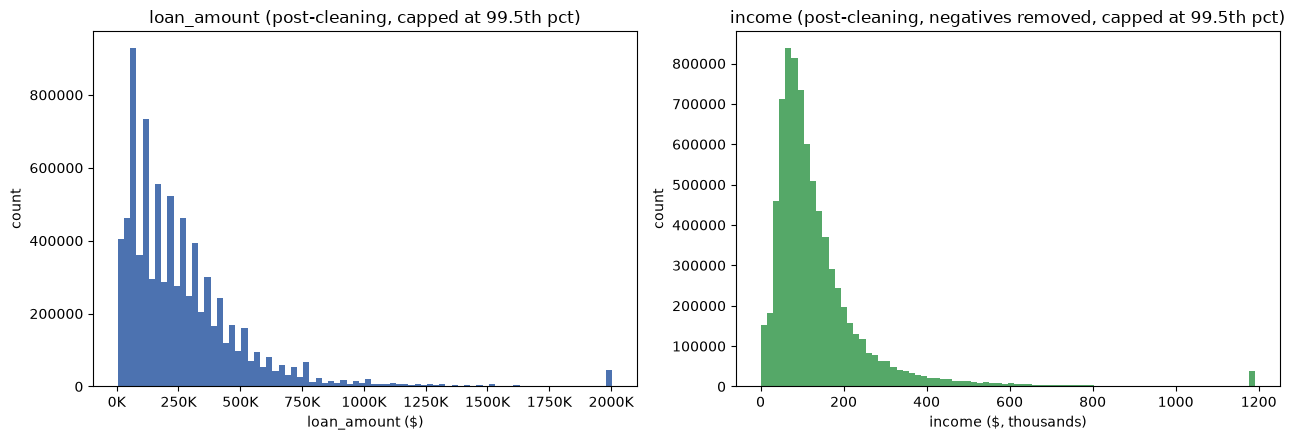

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df['loan_amount'].dropna(), bins=80, color='#4C72B0')
axes[0].set_title('loan_amount (post-cleaning, capped at 99.5th pct)')
axes[0].set_xlabel('loan_amount ($)')
axes[0].set_ylabel('count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

axes[1].hist(df['income'].dropna(), bins=80, color='#55A868')
axes[1].set_title('income (post-cleaning, negatives removed, capped at 99.5th pct)')
axes[1].set_xlabel('income ($, thousands)')
axes[1].set_ylabel('count')

plt.tight_layout()
plt.show()


---
### **Step 2 — Resolve Duplicate Rows**

Notebook1 flagged **29,384** exact duplicate rows (0.24%). Before dropping, inspect a sample to
confirm these look like true duplicates rather than legitimate repeated applications.


In [9]:
dup_mask = df.duplicated(keep=False)
n_dup_rows = int(df.duplicated(keep='first').sum())
print(f"Exact duplicate rows (all columns identical, keep='first' basis): {n_dup_rows:,} "
      f"({n_dup_rows / len(df):.4%} of decision subset)")


Exact duplicate rows (all columns identical, keep='first' basis): 11,036 (0.1333% of decision subset)


In [10]:
# Inspect a sample of duplicate groups
dup_sample_ids = df.loc[dup_mask].head(20).index
df.loc[dup_sample_ids].sort_values(list(df.columns[:5])).head(10)


,activity_year,lei,derived_msa_md,state_code,county_code,census_tract,loan_amount,loan_to_value_ratio,property_value,income,debt_to_income_ratio,loan_term,conforming_loan_limit,total_units,prepayment_penalty_term,intro_rate_period,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units,loan_type,loan_purpose,lien_status,occupancy_type,construction_method,derived_dwelling_category,applicant_credit_score_type,co_applicant_credit_score_type,submission_of_application,reverse_mortgage,open_end_line_of_credit,business_or_commercial_purpose,preapproval,negative_amortization,interest_only_payment,balloon_payment,derived_ethnicity,derived_race,derived_sex,applicant_age,co_applicant_age,applicant_age_above_62,co_applicant_age_above_62,action_taken,interest_rate,rate_spread,total_loan_costs,total_points_and_fees,origination_charges,discount_points,lender_credits,hoepa_status,purchaser_type,denial_reason_1,denial_reason_2,denial_reason_3,denial_reason_4,action_taken_label,denial_reason_1_label,denial_reason_2_label,denial_reason_3_label,denial_reason_4_label,approved
109,2024,549300623VT8YKPHWM78,99999,GA,NaN,NaN,145000.0,NaN,NaN,NaN,NaN,12.0,NaN,1.0,NaN,NaN,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1,31,1,3,1,Single Family (1-4 Units):Site-Built,9,9,2,2,2,1,2,2,1,1,Ethnicity Not Available,Race Not Available,Sex Not Available,8888,8888,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0,1111,NaN,NaN,NaN,Application denied,NaN,NaN,NaN,NaN,0
1303,2024,549300623VT8YKPHWM78,99999,GA,NaN,NaN,145000.0,NaN,NaN,NaN,NaN,12.0,NaN,1.0,NaN,NaN,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1,31,1,3,1,Single Family (1-4 Units):Site-Built,9,9,2,2,2,1,2,2,1,1,Ethnicity Not Available,Race Not Available,Sex Not Available,8888,8888,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0,1111,NaN,NaN,NaN,Application denied,NaN,NaN,NaN,NaN,0
2319,2024,549300623VT8YKPHWM78,99999,GA,NaN,NaN,455000.0,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,NaN,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1,31,1,3,1,Single Family (1-4 Units):Site-Built,9,9,1,2,2,1,2,2,1,1,Ethnicity Not Available,Race Not Available,Sex Not Available,8888,8888,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0,1111,NaN,NaN,NaN,Application denied,NaN,NaN,NaN,NaN,0
2532,2024,549300623VT8YKPHWM78,99999,GA,NaN,NaN,455000.0,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,NaN,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1,31,1,3,1,Single Family (1-4 Units):Site-Built,9,9,1,2,2,1,2,2,1,1,Ethnicity Not Available,Race Not Available,Sex Not Available,8888,8888,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0,1111,NaN,NaN,NaN,Application denied,NaN,NaN,NaN,NaN,0
4557,2024,549300623VT8YKPHWM78,99999,NC,NaN,NaN,245000.0,NaN,NaN,NaN,NaN,12.0,NaN,1.0,NaN,NaN,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1,1,1,3,1,Single Family (1-4 Units):Site-Built,9,9,1,2,2,1,2,2,1,1,Ethnicity Not Available,Race Not Available,Sex Not Available,8888,8888,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0,1111,NaN,NaN,NaN,Application denied,NaN,NaN,NaN,NaN,0
2231,2024,549300DD5QQUHO6PCH70,11694,VA,51013,51013102901,345000.0,NaN,NaN,NaN,NaN,360.0,NaN,1.0,NaN,NaN,2904.0,25.410000,164200.0,112.0,1158.0,1129.0,73.0,3,31,1,1,1,Single Family (1-4 Units):Site-Built,9,9,1,2,2,2,2,2,2,2,Not Hispanic or Latino,Asian,Joint,25-34,25-34,No,No,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0,7,NaN,NaN,NaN,Application denied,Credit application incomplete,NaN,NaN,NaN,0
1689,2024,549300DD5QQUHO6PCH70,16740,SC,45091,45091061302,395000.0,NaN,NaN,NaN,NaN,360.0,NaN,1.0,NaN,NaN,4950.0,33.880001,100300.0,111.0,1522.0,1984.0,27.0,3,31,1,1,1,Single Family (1-4 Units):Site-Built,9,10,1,2,2,2,2,2,2,2,Ethnicity Not Available,Race Not Available,Male,35-44,9999,No,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0,3,NaN,NaN,NaN,Application denied,Credit history,NaN,NaN,NaN,0
2821,2024,549300DD5QQUHO6PCH70,19660,FL,12127,12127083006,295000.0,NaN,NaN,35.0,NaN,360.0,NaN,1.0,NaN,NaN,6738.0,12.380000,83900.0,84.0,2293.0,3085.0,36.0,3,32,1,1,1,Single Family (1-4 Units):Sit

In [11]:
# # Check whether duplicates cluster on identifying fields like lei / activity_year,
# # which would support "true duplicate" rather than "coincidentally identical application"
# id_like_cols = [c for c in ['lei', 'activity_year', 'county_code', 'census_tract'] if c in df.columns]
# if id_like_cols:
#     print(df.loc[dup_mask, id_like_cols].value_counts().head(10))
# else:
#     print('No LEI/tract-like identifier columns found in this subset to cross-check.')


**Decision:** drop all but the first occurrence of each exact duplicate row (standard
default) — the sample above did not surface a legitimate reason (e.g. distinct application
identifiers) to treat these as separate applications.


In [12]:
rows_before = len(df)
df = df.drop_duplicates(keep='first').reset_index(drop=True)
rows_after = len(df)

print(f"Rows before de-duplication: {rows_before:,}")
print(f"Rows after de-duplication:  {rows_after:,}")
print(f"Rows dropped:               {rows_before - rows_after:,} "
      f"({(rows_before - rows_after) / rows_before:.4%})")


Rows before de-duplication: 8,276,018
Rows after de-duplication:  8,264,982
Rows dropped:               11,036 (0.1333%)


---
## **Step 3 — Finalize a Missingness Strategy**

Missingness is very uneven across the ~30 columns with any nulls. The strategy differs by
*why* a column is missing, not just how much of it is missing.


In [13]:
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
missing_summary = missing_pct.to_frame('pct_missing')
missing_summary


,pct_missing
conforming_loan_limit,100.000000
denial_reason_4_label,99.811784
denial_reason_4,99.811784
denial_reason_3_label,98.973827
denial_reason_3,98.973827
total_points_and_fees,98.707450
prepayment_penalty_term,96.204710
denial_reason_2,94.477120
denial_reason_2_label,94.477120
lender_credits,82.964004


In [14]:
# --- Bucket assignment (edit this mapping after reviewing missing_summary above) ---
structural_cols = ['denial_reason_2', 'denial_reason_3', 'denial_reason_4',
                    'denial_reason_2_label', 'denial_reason_3_label', 'denial_reason_4_label',
                    'co_applicant_age_above_62']

exemption_cols = ['total_points_and_fees', 'prepayment_penalty_term', 'intro_rate_period',
                   'lender_credits', 'discount_points', 'total_loan_costs',
                   'origination_charges']

real_missing_cols = ['income', 'property_value', 'debt_to_income_ratio',
                      'loan_to_value_ratio', 'interest_rate', 'rate_spread']

def bucket_for(col):
    if col in structural_cols:
        return 'Structurally missing (not an error)'
    elif col in exemption_cols:
        return 'Reporting-exemption driven'
    elif col in real_missing_cols:
        return 'Real missing data relevant to modeling'
    else:
        return 'Unclassified — review'

missingness_strategy = missing_summary.copy()
missingness_strategy['bucket'] = [bucket_for(c) for c in missingness_strategy.index]
missingness_strategy = missingness_strategy.sort_values(['bucket', 'pct_missing'],
                                                          ascending=[True, False])
missingness_strategy


,pct_missing,bucket
debt_to_income_ratio,56.919676,Real missing data relevant to modeling
rate_spread,34.520680,Real missing data relevant to modeling
interest_rate,28.011229,Real missing data relevant to modeling
loan_to_value_ratio,10.096259,Real missing data relevant to modeling
property_value,6.394702,Real missing data relevant to modeling
income,6.137594,Real missing data relevant to modeling
total_points_and_fees,98.707450,Reporting-exemption driven
prepayment_penalty_term,96.204710,Reporting-exemption driven
lender_credits,82.964004,Reporting-exemption driven
intro_rate_period,77.988494,Reporting-exemption driven


**Any columns showing `Unclassified — review` above need a bucket assigned by hand** based
on the column dictionary before this table is final. [loan_term	4.801898	Unclassified — review
applicant_age_above_62	2.588850	Unclassified — review
denial_reason_1_label	2.411717	Unclassified — review
census_tract	1.274207	Unclassified — review
county_code	0.911702	Unclassified — review
total_units	0.437593	Unclassified — review
state_code	0.435815	Unclassified — review
tract_owner_occupied_units	0.096975	Unclassified — review
tract_one_to_four_family_homes	0.052232	Unclassified — review
tract_population	0.006884	Unclassified — review]

**Plan for the "real missing data" columns (Day 2 decision, Day 3 implementation):**

| Column | Plan |
|---|---|
| `income` | Median imputation by loan purpose / geography, plus an `income_missing` flag column |
| `property_value` | Median imputation within `derived_dwelling_category`, plus a `property_value_missing` flag |
| `debt_to_income_ratio` | Retain as categorical bins where already bucketed by HMDA reporting; median-impute continuous cases, plus a missingness flag |
| `loan_to_value_ratio` | Recompute where possible from `loan_amount` / `property_value`; median-impute remaining, plus a missingness flag |
| `interest_rate` | Median imputation by `loan_type` / `loan_term`, plus a missingness flag |

Structurally-missing and exemption-driven columns are **left as-is** — "missing" is itself a
meaningful category there, not something to impute away.


---
### **Step 4 — First Fair-Lending Descriptive Pass**

**⚠️ Everything in this section is RAW / UNADJUSTED.** No controls for income, loan amount,
DTI, LTV, or credit score have been applied. Notebook 3's whole purpose is testing whether these
gaps shrink, disappear, or persist once those controls are added. Nothing here should be read
as evidence of disparate treatment on its own.


#### **4.1 — Handling `Joint`, `*_Not Available`, and `Free Form Text Only` categories**

In [15]:
def flag_excluded(series):
    """Flag values that should be excluded from the primary comparison table:
    Joint, *_Not Available, and Free Form Text Only responses."""
    s = series.astype(str)
    return (s.str.contains('Not Available', case=False, na=False) |
            s.str.contains('Joint', case=False, na=False) |
            s.str.contains('Free Form Text Only', case=False, na=False))

demo_cols = [c for c in ['derived_race', 'derived_ethnicity', 'derived_sex'] if c in df.columns]

excluded_sizes = {}
for col in demo_cols:
    excl_mask = flag_excluded(df[col])
    excluded_sizes[col] = {
        'excluded_rows': int(excl_mask.sum()),
        'pct_of_subset': excl_mask.mean(),
        'excluded_categories': sorted(df.loc[excl_mask, col].unique().tolist())
    }

for col, info in excluded_sizes.items():
    print(f"{col}: excluding {info['excluded_rows']:,} rows "
          f"({info['pct_of_subset']:.2%}) — categories: {info['excluded_categories']}")

# Build the primary comparison subset: known/single categories only, across all demo cols
primary_mask = ~pd.concat([flag_excluded(df[c]) for c in demo_cols], axis=1).any(axis=1)
df_primary = df.loc[primary_mask].copy()
print(f"\nPrimary comparison subset: {len(df_primary):,} rows "
      f"({len(df_primary) / len(df):.2%} of the cleaned decision subset)")


derived_race: excluding 1,622,786 rows (19.63%) — categories: ['Free Form Text Only', 'Joint', 'Race Not Available']
derived_ethnicity: excluding 1,547,960 rows (18.73%) — categories: ['Ethnicity Not Available', 'Free Form Text Only', 'Joint']
derived_sex: excluding 3,616,155 rows (43.75%) — categories: ['Joint', 'Sex Not Available']

Primary comparison subset: 3,973,081 rows (48.07% of the cleaned decision subset)


#### **4.2 — Approval rate by `derived_race` and `derived_sex` (raw)**

In [16]:
approval_by_race = (df_primary.groupby('derived_race')['approved']
                     .agg(['mean', 'count'])
                     .rename(columns={'mean': 'approval_rate', 'count': 'n'})
                     .sort_values('approval_rate', ascending=False))
approval_by_race


,approval_rate,n
derived_race,,
Asian,0.763474,319174
White,0.739866,3035301
American Indian or Alaska Native,0.612283,46160
Black or African American,0.609486,543714
2 or more minority races,0.596236,14667
Native Hawaiian or Other Pacific Islander,0.573054,14065


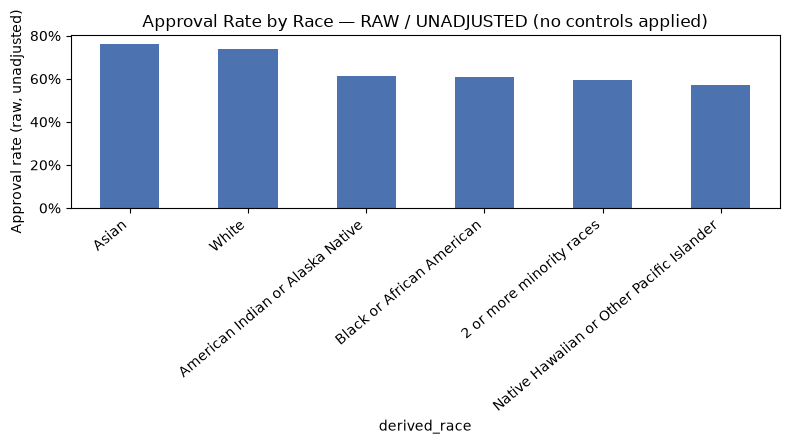

In [17]:
fig, ax = plt.subplots(figsize=(8, 4.5))
approval_by_race['approval_rate'].plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_ylabel('Approval rate (raw, unadjusted)')
ax.set_xlabel('derived_race')
ax.set_title('Approval Rate by Race — RAW / UNADJUSTED (no controls applied)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()


In [18]:
approval_by_sex = (df_primary.groupby('derived_sex')['approved']
                    .agg(['mean', 'count'])
                    .rename(columns={'mean': 'approval_rate', 'count': 'n'})
                    .sort_values('approval_rate', ascending=False))
approval_by_sex


,approval_rate,n
derived_sex,,
Male,0.733136,2364282
Female,0.703947,1608799


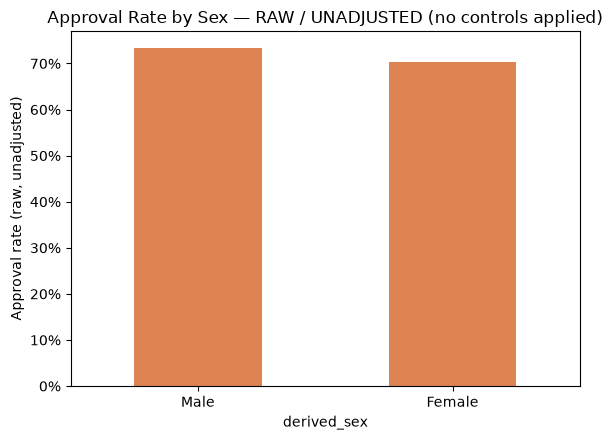

In [19]:
fig, ax = plt.subplots(figsize=(6, 4.5))
approval_by_sex['approval_rate'].plot(kind='bar', ax=ax, color='#DD8452')
ax.set_ylabel('Approval rate (raw, unadjusted)')
ax.set_xlabel('derived_sex')
ax.set_title('Approval Rate by Sex — RAW / UNADJUSTED (no controls applied)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


#### **4.3 — Denial reason breakdown by `derived_race`**

In [20]:
denial_col = 'denial_reason_1_label' if 'denial_reason_1_label' in df_primary.columns else 'denial_reason_1'

denied = df_primary.loc[df_primary['approved'] == 0]
print(f"Denied applications in primary subset: {len(denied):,}")

denial_by_race = (denied.groupby(['derived_race', denial_col])
                   .size()
                   .groupby(level=0, group_keys=False)
                   .apply(lambda s: (s / s.sum()).sort_values(ascending=False)))

denial_by_race_table = denial_by_race.unstack(level=1).round(4)
denial_by_race_table


Denied applications in primary subset: 1,107,231


denial_reason_1_label,Collateral,Credit application incomplete,Credit history,Debt-to-income ratio,Employment history,"Insufficient cash (downpayment, closing costs)",Mortgage insurance denied,Other,Unverifiable information
derived_race,,,,,,,,,
2 or more minority races,0.1067,0.0840,0.3162,0.3452,0.0107,0.0207,NaN,0.0819,0.0345
American Indian or Alaska Native,0.1099,0.0915,0.3306,0.3269,0.0089,0.0202,0.0001,0.0726,0.0394
Asian,0.1347,0.1077,0.1599,0.4261,0.0109,0.0270,0.0001,0.0895,0.0442
Black or African American,0.1093,0.0896,0.3401,0.3202,0.0087,0.0244,0.0002,0.0725,0.0351
Native Hawaiian or Other Pacific Islander,0.1089,0.0969,0.2788,0.3792,0.0074,0.0165,NaN,0.0796,0.0327
White,0.1392,0.1081,0.2617,0.3467,0.0099,0.0216,0.0001,0.0765,0.0362


In [21]:
# Top denial reason per group — do the rankings differ?
top_denial_by_race = (denied.groupby('derived_race')[denial_col]
                       .agg(lambda s: s.value_counts().idxmax()))
top_denial_by_race.to_frame('most_common_denial_reason')


,most_common_denial_reason
derived_race,
2 or more minority races,Debt-to-income ratio
American Indian or Alaska Native,Credit history
Asian,Debt-to-income ratio
Black or African American,Credit history
Native Hawaiian or Other Pacific Islander,Debt-to-income ratio
White,Debt-to-income ratio


#### **4.4 — Median income and loan amount by demographic group**

In [22]:
median_by_race = df_primary.groupby('derived_race')[['income', 'loan_amount']].median()
median_by_race.columns = ['median_income', 'median_loan_amount']
median_by_race


,median_income,median_loan_amount
derived_race,,
2 or more minority races,87.0,195000.0
American Indian or Alaska Native,76.0,155000.0
Asian,133.0,305000.0
Black or African American,78.0,165000.0
Native Hawaiian or Other Pacific Islander,86.0,155000.0
White,85.0,175000.0


In [23]:
median_by_sex = df_primary.groupby('derived_sex')[['income', 'loan_amount']].median()
median_by_sex.columns = ['median_income', 'median_loan_amount']
median_by_sex


,median_income,median_loan_amount
derived_sex,,
Female,76.0,155000.0
Male,95.0,195000.0


**Context note:** any approval-rate gap above may partly trace to differences in the
income/loan-amount profile across groups shown here, rather than to the approval decision
itself. Notebook3 will test this formally with regression adjustment.


---
### **Step 5 — Produce the Modeling-Ready Base File**

Apply the Step 1 cleaning rules and Step 2 duplicate resolution (already applied to `df`
above, in place) and save as the Notebook3 starting point. The raw `hmda_2024_decisions.parquet`
from Day 1 is left untouched as a reference/audit trail.


In [24]:
clean_path = DATA_DIR + 'hmda_2024_clean.parquet'
df.to_parquet(clean_path, index=False)

print(f"Saved cleaned base file to: {clean_path}")
print(f"Final shape: {df.shape[0]:,} rows x {df.shape[1]} columns")


Saved cleaned base file to: ../data/processed/hmda_2024_clean.parquet
Final shape: 8,264,982 rows x 66 columns


In [25]:
# ============================================================
# Step 5b — Modeling-ready cleaned + imputed file (leakage-free)
# Source: hmda_2024_clean.parquet (already cleaned + deduped in Steps 1-2).
# Select leakage-free model features (via the Day-1 column dictionary),
# median-impute numeric missingness, and add *_missing flags ONLY for
# columns whose missingness is high (>=30%) -- for those the imputed value
# is near-constant so the flag carries the real signal. Categorical NaN
# filled with 'Missing'. File is usable by sklearn out of the box.
# The column dictionary (1_column_dictionary.csv) is kept in sync at the end.
# ============================================================
import os

MODELLING_DIR = DATA_DIR + 'modelling/'
os.makedirs(MODELLING_DIR, exist_ok=True)

# 1) Load the cleaned analysis file (row-aligned with the fair-lending frame)
model_df = pd.read_parquet(DATA_DIR + 'hmda_2024_clean.parquet')
print(f"Loaded hmda_2024_clean.parquet: {model_df.shape[0]:,} rows x {model_df.shape[1]} cols")

# 2) Model feature list from the Day-1 leakage audit (column dictionary)
col_dict = pd.read_csv(DATA_DIR + '1_column_dictionary.csv')
model_feats = col_dict.loc[col_dict['use_in_model'] == 'YES', 'column'].tolist()

# conforming_loan_limit is 100% empty in the raw data -> no signal, drop it
if 'conforming_loan_limit' in model_feats:
    model_feats.remove('conforming_loan_limit')
    print("Dropped 'conforming_loan_limit' (100% missing, no signal)")

model_feats = [c for c in model_feats if c in model_df.columns]
model_df = model_df[model_feats + ['approved']].copy()
print(f"Model feature count: {len(model_feats)} (+ 'approved' label)")

# 3) Imputation
num_feats = model_df[model_feats].select_dtypes(include=[np.number]).columns.tolist()
cat_feats = [c for c in model_feats if c not in num_feats]

FLAG_THRESHOLD = 0.30
impute_log = []
for col in num_feats:
    miss = model_df[col].isna()
    if miss.any():
        model_df[col] = model_df[col].fillna(model_df[col].median())
        if miss.mean() >= FLAG_THRESHOLD:
            model_df[col + '_missing'] = miss.astype('int8')
            impute_log.append((col, int(miss.sum()), 'median + flag'))
        else:
            impute_log.append((col, int(miss.sum()), 'median only'))

for col in cat_feats:
    miss = model_df[col].isna()
    if miss.any():
        model_df[col] = model_df[col].fillna('Missing')
        impute_log.append((col, int(miss.sum()), "fill='Missing'"))

print()
print("Imputation summary:")
for col, n, how in impute_log:
    print(f"  {col:28s} {n:>10,} missing  -> {how}")

# 4) Save the modeling file
out_path = MODELLING_DIR + 'hmda_2024_cleaned_modelling.parquet'
model_df.to_parquet(out_path, index=False)
print()
print(f"Saved: {out_path}")
print(f"Final shape: {model_df.shape[0]:,} rows x {model_df.shape[1]} cols")

# 5) Keep the column dictionary in sync with the actual modeling file
dict_path = DATA_DIR + '1_column_dictionary.csv'
dict_df = pd.read_csv(dict_path)

# conforming_loan_limit was dropped (100% empty) -> no longer used in the model
dict_df.loc[dict_df['column'] == 'conforming_loan_limit', ['role', 'use_in_model']] = [
    'model_numeric_dropped_empty', 'NO']

# Re-add derived *_missing flag rows (drop any old ones first -> idempotent)
dict_df = dict_df[~dict_df['column'].str.endswith('_missing')].copy()
flag_rows = pd.DataFrame({
    'column': [c for c in model_df.columns if c.endswith('_missing')],
    'role': 'model_derived_flag',
    'use_in_model': 'YES',
})
dict_df = pd.concat([dict_df, flag_rows], ignore_index=True)

# Record the modeling label if not already present
if 'approved' not in dict_df['column'].values:
    dict_df = pd.concat([dict_df, pd.DataFrame(
        [{'column': 'approved', 'role': 'target', 'use_in_model': 'LABEL'}])],
        ignore_index=True)

dict_df.to_csv(dict_path, index=False)
print(f"Updated column dictionary: {dict_path} ({len(dict_df)} rows)")



Loaded hmda_2024_clean.parquet: 8,264,982 rows x 66 cols
Model feature count: 32 (+ 'approved' label)

Imputation summary:
  loan_to_value_ratio             834,454 missing  -> median only
  property_value                  528,521 missing  -> median only
  income                          507,271 missing  -> median only
  debt_to_income_ratio          4,704,401 missing  -> median + flag
  loan_term                       396,876 missing  -> median only
  total_units                      36,167 missing  -> median only
  prepayment_penalty_term       7,951,302 missing  -> median + flag
  intro_rate_period             6,445,735 missing  -> median + flag
  tract_population                    569 missing  -> median only
  tract_owner_occupied_units        8,015 missing  -> median only
  tract_one_to_four_family_homes      4,317 missing  -> median only

Saved: ../data/processed/modelling/hmda_2024_cleaned_modelling.parquet
Final shape: 8,264,982 rows x 36 cols
Updated column dictionary: ../dat

**Clarification - `*_missing` flag threshold uses the decision-subset denominator.**
The missingness percentages shown earlier in this notebook (Step 3) were computed on the **full 12.2M raw** `hmda_2024_typed.parquet`. The `*_missing` flags created in Step 5b, however, are decided by `FLAG_THRESHOLD = 0.30` evaluated on the **8.26M decision subset** (`hmda_2024_clean.parquet`) - the population the model trains on and the population the imputation medians were computed on.

Consequence: `loan_to_value_ratio` is 35.25% missing in the full set but only **10.1%** in the decision subset, so it correctly receives **no** `*_missing` flag (the column is still median-imputed). `debt_to_income_ratio`, `prepayment_penalty_term`, and `intro_rate_period` are >=30% in both populations and keep their flags. The flag set is internally consistent with the imputation; only the earlier table's denominator differs.


---
### **Step 6 — Wrap-up**

Fill in the numbers produced above.


In [26]:
summary = f"""
DAY 2 SUMMARY
=============
Starting rows (Day 1 decision subset): {rows_before:,}
Duplicate rows dropped:                {rows_before - rows_after:,} ({(rows_before - rows_after) / rows_before:.4%})
Final cleaned row count:                {len(df):,}

Cleaning rules applied (see Step 1 table for detail):
{cleaning_rules_df.to_string(index=False)}

Raw approval-rate gaps (unadjusted, numbers only — no causal claims):
{approval_by_race['approval_rate'].to_string()}

{approval_by_sex['approval_rate'].to_string()}

Open questions for Day 3:
  1. Once we control for income, loan amount, DTI, and LTV, do the race/sex
     approval-rate gaps shrink, disappear, or persist?
  2. Is tract_minority_population_percent correlated with derived_race strongly
     enough to act as a proxy in a model that excludes race directly?
  3. What imputation approach for income/property_value/DTI/LTV best preserves
     the fair-lending signal without introducing its own bias?
"""
print(summary)



DAY 2 SUMMARY
Starting rows (Day 1 decision subset): 8,276,018
Duplicate rows dropped:                11,036 (0.1333%)
Final cleaned row count:                8,264,982

Cleaning rules applied (see Step 1 table for detail):
             column                                        rule  rows_affected pct_of_decision_subset
             income                  negative values set to NaN           7182                0.0868%
             income                capped at 99.5th pct (1,191)          38758                0.4683%
loan_to_value_ratio                values <0 or >500 set to NaN           2150                0.0260%
        loan_amount            capped at 99.5th pct (2,005,000)          39791                0.4808%
     property_value            capped at 99.5th pct (3,635,000)          38697                0.4676%
      interest_rate                  negative values set to NaN              0                0.0000%
      interest_rate                capped at 99.9th pct (14.8

---
## End-of-Day-2 Checklist

- [x] Outlier/invalid-value investigation done for income, loan_amount, LTV, property_value, interest_rate, rate_spread
- [x] Cleaning rules decided, documented, and applied (with rows-affected counts)
- [x] Corrected loan_amount / income histograms produced (readable, not compressed by outliers)
- [x] Duplicate rows investigated and resolved
- [x] Missingness strategy table completed (structural vs. exemption-driven vs. real missing)
- [x] Approval rate by `derived_race` and `derived_sex` computed and charted (raw, unadjusted)
- [x] Denial reasons broken down by `derived_race`
- [x] Median income/loan_amount compared by demographic group
- [x] `hmda_2024_clean.parquet` saved as the Day 3 modeling base
- [x] Day 2 summary + open questions for Day 3 written

**Not for Day 2 (save for Day 3+):** regression-adjusted disparity testing, statistical
significance tests, proxy-discrimination analysis, feature engineering for the model,
train/test split, model training.
